In [ ]:
https://github.com/iandriyash/ai-arhictect-2026-demo

# 1-я промежуточная аттестация

**Тема:** банковский сектор — веб-приложение на основе ИИ для прогноза просрочки по
розничному кредиту.

**База:** `bank_ii`, синтетический розничный банк, PostgreSQL.

**Состав работы:** этот ноутбук, `attest_1_create_view.sql`, `loan_overdue_mart.csv`.

Перед тем как строить витрину, я отдельными запросами в pgAdmin посмотрел, из чего вообще
состоит база. Результаты:

| Что проверял | Что получилось |
|---|---|
| Статусы кредита | только `APPLIED` 323 и `ACTIVE` 2616; статуса `DEFAULT` в базе нет |
| Кредитов всего | 2939, из них с платежами 2477, без платежей 462 |
| Витрина | 2477 строк, 511 с `is_overdue = 1`, это 20.6% |
| Платежи | `PAID` 12399, `LATE` 593, всего 12992 строки |
| Горизонт | выдачи 2025-01-07 … 2025-12-01, платежи 2025-02-07 … 2026-01-17 |
| Клиенты | 2381 клиент с одним кредитом, 279 с двумя |

Объект моделирования — кредит. Не клиент и не заявка.

## 1. Бизнес-задача

Банк теряет деньги, когда розничный заёмщик уходит в просрочку: растут резервы, растёт
стоимость сбора — звонки, письма, взыскание, — падает оборачиваемость портфеля.

Задача для бизнеса: заранее находить кредиты с повышенным риском ранней просрочки, чтобы до
наступления проблемы усилить мониторинг (напоминание за три дня, сдвиг даты платежа под
зарплату), предложить реструктуризацию или хотя бы не расширять лимит и не выдавать этому
клиенту второй кредит.

Тема работы — веб-приложение, в которое кредитный инспектор вводит параметры сделки на дату
выдачи и получает оценку риска вместе с объяснением, какие факторы её сформировали. Отсюда
требование к будущей модели: она должна быть объяснимой, а не только точной.

## 2. Задача машинного обучения

Тип задачи — бинарная классификация, обучение с учителем.

Единица наблюдения — розничный кредит, по которому уже начался график платежей.

Вопрос, на который отвечает модель: будет ли по этому кредиту хотя бы один просроченный
платёж со статусом `LATE`.

Чего я здесь **не** делаю: это не предсказание дефолта. В базе нет статуса `DEFAULT`, нет
данных о выходе на 90+ дней и нет информации о списаниях. Я моделирую факт ранней просрочки
платежа — операционный показатель, а не регуляторный.

Обучение модели — следующий этап курса. Задача этой работы: собрать витрину, проверить её на
утечки и понять, есть ли в данных сигнал.

## 2.1 Окно признаков и окно наблюдения

База — снимок на дату, а не поток заявок. Окна я всё равно фиксирую явно, иначе цель легко
собрать «из будущего».

**Окно признаков** — момент выдачи `disbursement_date`. Здесь известны сумма, ставка, срок,
продукт, возраст, доход, статус занятости, отрасль.

**Окно наблюдения** — поведение после выдачи. Событие: хотя бы один платёж `LATE`.

**Невызревшие кредиты** — 462 договора без единого платежа. Пометить их нулём нельзя: штрафа
нет не потому, что заёмщик надёжный, а потому что график ещё не начался. Поэтому в VIEW стоит
`INNER JOIN` к платежам, и остаётся 2477 строк. Из 462 невызревших 323 имеют статус `APPLIED`
(кредит ещё не выдан), 139 — `ACTIVE`, выданы недавно, первый платёж не наступил.

Отсюда следствие, которое пригодится дальше: в витрине остались только кредиты со статусом
`ACTIVE`, то есть `loan_status_id` внутри неё — константа и признаком быть не может.

Есть ещё одно ограничение, и оно оказалось главным в этой работе: окно наблюдения у разных
кредитов получилось разной длины. Январская выдача наблюдается примерно одиннадцать платежей,
ноябрьская — один. Событие «хотя бы один `LATE`» накапливается со временем, поэтому сырой
`is_overdue` не сопоставим между кредитами. Подробно разбираю это в блоках 7.3 и 8.2.

`gender_id` я смотрю только в разведочном анализе, чтобы понимать структуру портфеля, и в
признаки модели не беру: использование пола в скоринге — это вопрос дискриминации, а не ещё
одна колонка в таблице.

## 3. Целевая переменная и объясняющие признаки

**Целевая `is_overdue`:** 1, если по кредиту был хотя бы один платёж со статусом `LATE`
(`payment_status_id = 2`), иначе 0. В витрине 2477 кредитов, из них 511 единиц — 20.6%.

Это ранняя просрочка, а не юридический дефолт.

**Признаки модели.** Все известны на дату выдачи:

| Группа | Поля |
|---|---|
| Кредит | `principal_amount`, `interest_rate`, `term_months`, `loan_product_id` |
| Клиент | `customer_age`, `customer_status_id` |
| Занятость | `annual_income`, `employment_status_id`, `industry_id` |
| Производные | `loan_to_income`, `income_missing`, `is_young_borrower` |
| Контроль длины наблюдения | `payments_cnt` — не как признак заёмщика, см. блок 8.2 |

**Что остаётся только для разведочного анализа:**

- `gender_id` — демография;
- `late_cnt`, `late_fee_sum`, `avg_delay_days` — утечка целевой переменной: эти поля
  считаются уже после события. Если положить их в модель, она запомнит факт штрафа и покажет
  на витрине почти идеальное качество, а в момент принятия решения о выдаче этих полей просто
  не существует;
- `loan_status_id` и `loan_status` — константа внутри витрины.

Служебные `late_*` я осознанно оставил в csv: это документация того, как собрана цель, и
материал для проверки на утечку в блоке 8.1.

## 4. Подключение к БД, создание VIEW и загрузка витрины

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Папка с ноутбуком. При необходимости поправьте путь.
BASE = Path.cwd()
ENV_PATH = BASE / ".env"
SQL_VIEW_PATH = BASE / "attest_1_create_view.sql"
SQL_PATH = BASE / "attest_1.sql"
EXPORT_PATH = BASE / "loan_overdue_mart.csv"

print("Файл .env найден:", ENV_PATH.exists())
print("Файл attest_1_create_view.sql найден:", SQL_VIEW_PATH.exists())
print("Файл attest_1.sql найден:", SQL_PATH.exists())

Файл .env найден: True
Файл attest_1_create_view.sql найден: True
Файл attest_1.sql найден: True


In [2]:
def read_sql_script(sql_path):
    # SQL держим в отдельных файлах, а не в строках Python
    with open(sql_path, "r", encoding="utf-8") as file:
        return file.read()


def create_connection_url(env_path):
    # Пароль берём из .env: в ноутбуке он не хранится и в сдачу не попадает
    from dotenv import load_dotenv
    load_dotenv(env_path)
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    database = os.getenv("DB_NAME")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")
    return f"postgresql://{user}:{password}@{host}:{port}/{database}"


def load_mart():
    # Основной путь: создать/обновить VIEW в PostgreSQL и забрать витрину в pandas.
    # Резервный путь: если БД недоступна (проверка на другой машине) - читаем csv.
    # Логика анализа от источника данных не зависит.
    try:
        from sqlalchemy import create_engine, text
        engine = create_engine(create_connection_url(ENV_PATH))
        create_sql = read_sql_script(SQL_VIEW_PATH)
        select_sql = read_sql_script(SQL_PATH)
        with engine.begin() as conn:
            conn.execute(text(create_sql))
        frame = pd.read_sql(text(select_sql), engine)
        return frame, "PostgreSQL / v_loan_overdue_mart"
    except Exception as err:
        print("БД недоступна, читаю выгрузку csv. Причина:", type(err).__name__, err)
        return pd.read_csv(EXPORT_PATH), "CSV / loan_overdue_mart.csv"


df, SOURCE = load_mart()
print("Источник данных:", SOURCE)
print("Строк в витрине:", df.shape[0])
print("Столбцов:", df.shape[1])
df.head()

Источник данных: PostgreSQL / v_loan_overdue_mart
Строк в витрине: 2477
Столбцов: 21


,loan_id,customer_id,loan_product_id,loan_status_id,loan_status,principal_amount,interest_rate,term_months,disbursement_date,customer_age,gender_id,customer_status_id,employment_status_id,industry_id,annual_income,loan_to_income,payments_cnt,late_cnt,late_fee_sum,avg_delay_days,is_overdue
0,1,6,2,3,ACTIVE,"9,359,671.450",13.420,120,2025-09-11,25,1,1,1,7.000,"2,154,655.920",4.344,3,0,0.000,NaN,0
1,4,22,1,3,ACTIVE,"1,088,267.740",24.064,12,2025-11-25,64,1,1,1,11.000,"7,672,814.400",0.142,1,0,0.000,NaN,0
2,5,23,1,3,ACTIVE,"369,542.040",17.287,60,2025-08-26,34,1,3,1,10.000,"2,618,852.760",0.141,4,0,0.000,NaN,0
3,6,27,2,3,ACTIVE,"6,715,317.590",10.909,120,2025-04-13,55,2,1,1,3.000,"1,285,964.040",5.222,8,0,0.000,NaN,0
4,7,28,1,3,ACTIVE,"296,854.980",18.072,12,2025-07-23,46,2,1,2,5.000,"2,732,976.600",0.109,5,0,0.000,NaN,0


In [3]:
# Контроль гранулярности: 1 строка = 1 кредит
print("Уникальных loan_id:", df["loan_id"].nunique(), "при", len(df), "строках")
print("Дубликатов по loan_id:", int(df["loan_id"].duplicated().sum()))
print("Уникальных клиентов:", df["customer_id"].nunique())
print()
print("Статус кредита внутри витрины:")
print(df["loan_status"].value_counts())
print("\nВывод: APPLIED-кредитов в витрине нет — у них нет платежей.")
print("loan_status_id — константа, в признаки не берём.")

Уникальных loan_id: 2477 при 2477 строках
Дубликатов по loan_id: 0
Уникальных клиентов: 2216

Статус кредита внутри витрины:
loan_status
ACTIVE    2477
Name: count, dtype: int64

Вывод: APPLIED-кредитов в витрине нет — у них нет платежей.
loan_status_id — константа, в признаки не берём.


## 5. Выгрузка витрины в CSV

In [4]:
df.to_csv(EXPORT_PATH, index=False)
print("Сохранено:", EXPORT_PATH.name)
print("Размер файла, КБ:", round(EXPORT_PATH.stat().st_size / 1024, 1))
print("Колонок в выгрузке:", df.shape[1])

Сохранено: loan_overdue_mart.csv
Размер файла, КБ: 265.3
Колонок в выгрузке: 21


## 6. Разведочный анализ данных

### 6.1 Типы, пропуски, целевая, числовые признаки

In [5]:
print("Типы данных:")
display(df.dtypes.to_frame("dtype"))

print("\nПропуски:")
missing = df.isna().sum().to_frame("nulls")
missing["share"] = missing["nulls"] / len(df)
display(missing[missing["nulls"] > 0].sort_values("nulls", ascending=False))

print("\nЦелевая переменная:")
target = df["is_overdue"].value_counts().rename("count").to_frame()
target["share"] = target["count"] / target["count"].sum()
display(target)

print("\nОписательная статистика числовых полей:")
num_cols = [
    "principal_amount", "interest_rate", "term_months",
    "customer_age", "annual_income", "loan_to_income",
    "payments_cnt", "late_cnt", "late_fee_sum",
]
display(df[num_cols].describe())

Типы данных:


,dtype
loan_id,int64
customer_id,int64
loan_product_id,int64
loan_status_id,int64
loan_status,str
principal_amount,float64
interest_rate,float64
term_months,int64
disbursement_date,object
customer_age,int64



Пропуски:


,nulls,share
avg_delay_days,1966,0.794
industry_id,95,0.038
loan_to_income,8,0.003



Целевая переменная:


,count,share
is_overdue,,
0,1966,0.794
1,511,0.206



Описательная статистика числовых полей:


,principal_amount,interest_rate,term_months,customer_age,annual_income,loan_to_income,payments_cnt,late_cnt,late_fee_sum
count,"2,477.000","2,477.000","2,477.000","2,477.000","2,477.000","2,469.000","2,477.000","2,477.000","2,477.000"
mean,"2,769,276.638",17.361,104.623,44.791,"2,296,362.461",1.590,5.245,0.239,277.399
std,"2,994,147.858",4.426,96.452,12.030,"1,339,002.497",3.079,2.523,0.507,635.558
min,"100,915.730",10.008,12.000,18.000,0.000,0.022,1.000,0.000,0.000
25%,"557,503.570",13.278,36.000,35.000,"1,419,009.480",0.282,3.000,0.000,0.000
50%,"1,042,061.940",17.603,60.000,44.000,"1,964,831.280",0.561,5.000,0.000,0.000
75%,"4,960,516.990",21.157,180.000,54.000,"2,762,145.960",2.036,7.000,0.000,0.000
max,"9,980,470.050",24.996,300.000,80.000,"8,476,093.680",86.015,11.000,4.000,"4,947.540"


Пропуски здесь трёх разных природ, поэтому и обрабатываю их по-разному.

`avg_delay_days` — 1966 пропусков. Природа структурная: задержки не было, среднее не
определено. Ничем не заполняю. Подставить ноль было бы прямой ошибкой: «задержки не было» и
«задержка ноль дней» после этого совпадут численно, хотя смысл у них разный. К тому же поле
всё равно не идёт в модель.

`industry_id` — 95 пропусков. Отрасль не указана. Делаю из этого отдельную категорию, а не
подставляю моду.

`loan_to_income` — 8 пропусков. Это деление на ноль при нулевом доходе. Ставлю флаг
`income_missing`, строку не удаляю.

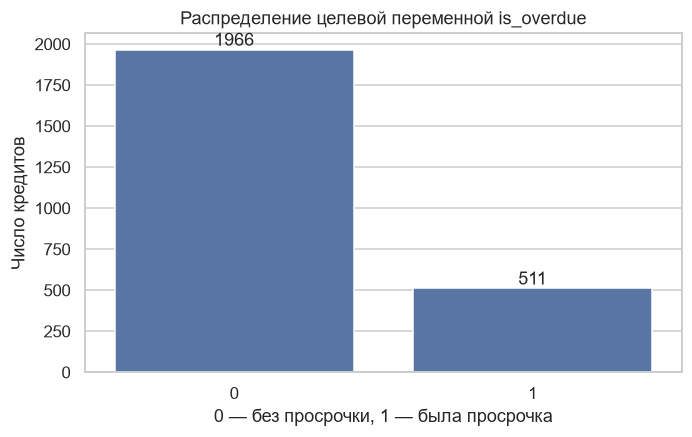

Baseline «всем ставить 0»: accuracy = 79.4%


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="is_overdue", ax=ax)
ax.set_title("Распределение целевой переменной is_overdue")
ax.set_xlabel("0 — без просрочки, 1 — была просрочка")
ax.set_ylabel("Число кредитов")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

share0 = (df["is_overdue"] == 0).mean()
print(f"Baseline «всем ставить 0»: accuracy = {share0:.1%}")

Получилось 1966 кредитов без просрочки — 79.4%, и 511 с просрочкой — 20.6%.

Отсюда сразу видно ограничение по метрике. Наивное правило «всем ставить ноль» даёт accuracy
79.4%. Это не качество модели, это доля большего класса. Поэтому accuracy дальше не
использую — нужны ROC-AUC, PR-AUC, precision, recall, F1.

Дисбаланс 79 на 21 для розницы умеренный. Искусственно выравнивать классы я не планирую:
синтетические объекты в кредитном риске портят калибровку вероятности, а бизнесу нужна именно
вероятность, а не только метка.

### 6.2 Категориальные признаки

По числовым полям, как будет видно в блоке 7, медианы классов почти совпадают. Но
категориальные признаки боксплотом не проверишь — там нужны доля просрочки по уровням,
критерий хи-квадрат на независимость и Cramér's V как мера силы связи.

In [7]:
def cramers_v(a, b):
    # Мера силы связи двух категориальных переменных: 0 = нет связи, 1 = функциональная
    table = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(table).statistic
    n = table.to_numpy().sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


CAT_COLS = [
    "loan_product_id", "customer_status_id",
    "employment_status_id", "industry_id", "gender_id",
]

rows = []
for col in CAT_COLS:
    filled = df[col].fillna(-1)
    table = pd.crosstab(filled, df["is_overdue"])
    chi = stats.chi2_contingency(table)
    rows.append({
        "feature": col,
        "levels": filled.nunique(),
        "chi2_p_value": chi.pvalue,
        "cramers_v": cramers_v(filled, df["is_overdue"]),
    })

cat_summary = pd.DataFrame(rows).sort_values("chi2_p_value")
print("Связь категориальных признаков с целью (p < 0.05 — связь статистически значима):")
display(cat_summary)

Связь категориальных признаков с целью (p < 0.05 — связь статистически значима):


,feature,levels,chi2_p_value,cramers_v
2,employment_status_id,4,0.001,0.079
3,industry_id,13,0.052,0.092
1,customer_status_id,3,0.331,0.030
4,gender_id,2,0.949,0.001
0,loan_product_id,2,0.965,0.001


In [8]:
def rate_table(frame, col):
    filled = frame[col].fillna(-1)
    out = frame.groupby(filled, observed=True)["is_overdue"].agg(
        loans="size", overdue_rate="mean"
    )
    out["lift"] = out["overdue_rate"] / frame["is_overdue"].mean()
    return out

for col in ["employment_status_id", "industry_id", "customer_status_id", "gender_id"]:
    print(f"--- Доля просрочки по {col} (lift = во сколько раз выше среднего 20.6%)")
    display(rate_table(df, col).round(3))

--- Доля просрочки по employment_status_id (lift = во сколько раз выше среднего 20.6%)


,loans,overdue_rate,lift
employment_status_id,,,
1,2115,0.195,0.947
2,267,0.292,1.416
3,54,0.259,1.257
4,41,0.146,0.709


--- Доля просрочки по industry_id (lift = во сколько раз выше среднего 20.6%)


,loans,overdue_rate,lift
industry_id,,,
-1.000,95,0.211,1.020
1.000,182,0.236,1.145
2.000,175,0.234,1.136
3.000,203,0.212,1.027
4.000,200,0.200,0.969
5.000,201,0.189,0.916
6.000,210,0.219,1.062
7.000,213,0.141,0.683
8.000,207,0.179,0.866


--- Доля просрочки по customer_status_id (lift = во сколько раз выше среднего 20.6%)


,loans,overdue_rate,lift
customer_status_id,,,
1,2285,0.205,0.993
2,140,0.200,0.969
3,52,0.288,1.398


--- Доля просрочки по gender_id (lift = во сколько раз выше среднего 20.6%)


,loans,overdue_rate,lift
gender_id,,,
1,1279,0.207,1.004
2,1198,0.205,0.995


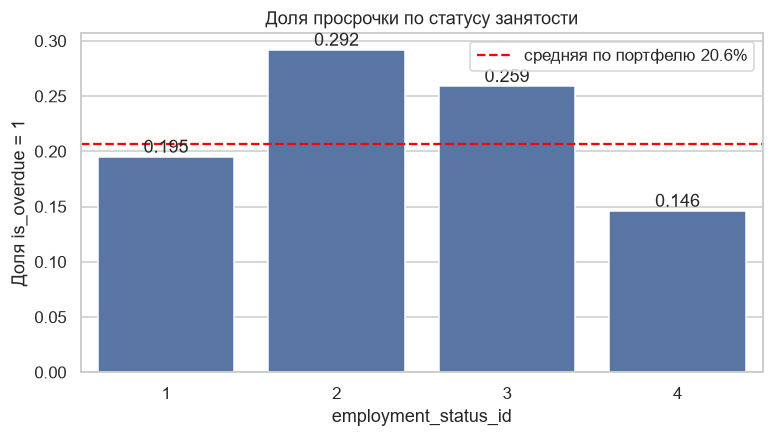

In [9]:
emp = rate_table(df, "employment_status_id").reset_index()
emp.columns = ["employment_status_id", "loans", "overdue_rate", "lift"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=emp, x="employment_status_id", y="overdue_rate", ax=ax, color="#4C72B0")
ax.axhline(df["is_overdue"].mean(), color="red", ls="--",
           label=f"средняя по портфелю {df['is_overdue'].mean():.1%}")
ax.set_title("Доля просрочки по статусу занятости")
ax.set_ylabel("Доля is_overdue = 1")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
ax.legend()
plt.show()

Из пяти категориальных признаков связь с целью нашлась у одного, и ещё один оказался на
границе.

`employment_status_id` — хи-квадрат даёт p = 0.0015, связь значима. Статус 2 даёт 29.2%
просрочки против 19.5% у статуса 1, то есть примерно в 1.4 раза выше среднего по портфелю.
Смысл понятный: важна не столько величина дохода, сколько его регулярность. Нестабильная
занятость — неровный денежный поток — пропущенная дата платежа.

`industry_id` — p = 0.052, на границе. Разброс от 14.1% в отрасли 7 до 29.1% в отрасли 10.
При двенадцати уровнях и примерно двухстах наблюдениях в каждом часть этого разброса — шум.
Поэтому брать двенадцать отдельных категорий я бы не стал, разумнее сгруппировать отрасли в
три корзины.

`customer_status_id` (p = 0.33), `loan_product_id` (p = 0.96) и `gender_id` (p = 0.95) связи
с целью не показывают.

Про пол отдельно. Я исключил его из признаков до анализа, по соображениям комплаенса. Уже
потом оказалось, что и сигнала в нём нет: Cramér's V = 0.001. То есть это ограничение ничего
не стоит банку в качестве модели.

## 7. Графики связи признаков и целевой переменной

### 7.1 Числовые признаки по классам

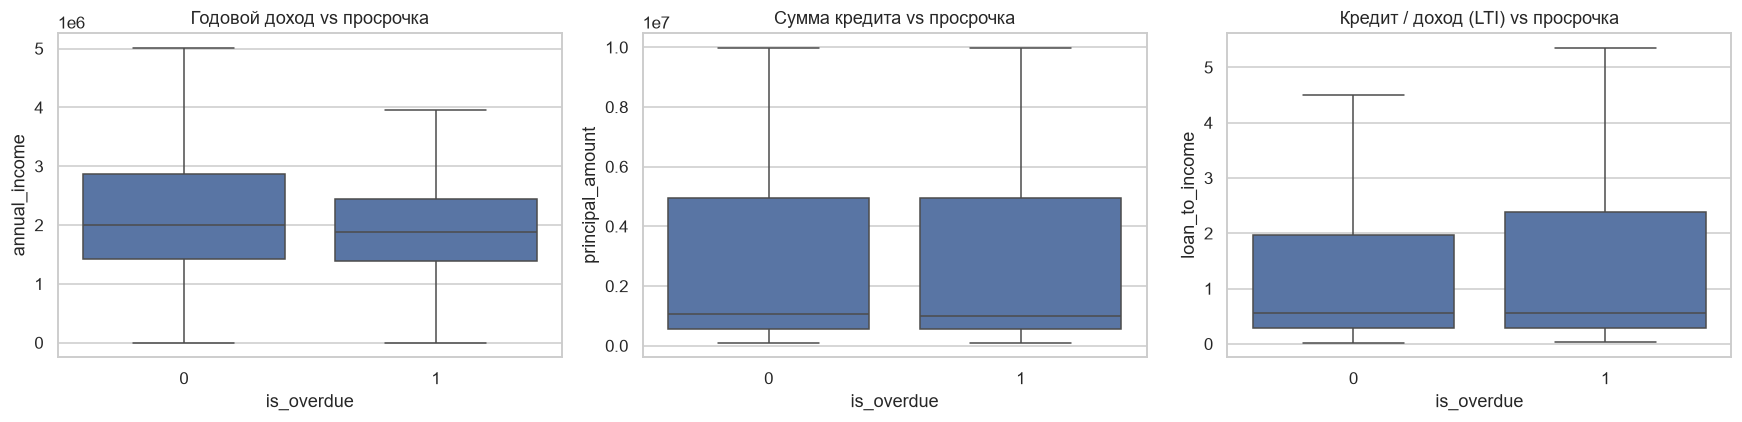

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="is_overdue", y="annual_income", ax=axes[0], showfliers=False)
axes[0].set_title("Годовой доход vs просрочка")

sns.boxplot(data=df, x="is_overdue", y="principal_amount", ax=axes[1], showfliers=False)
axes[1].set_title("Сумма кредита vs просрочка")

sns.boxplot(data=df, x="is_overdue", y="loan_to_income", ax=axes[2], showfliers=False)
axes[2].set_title("Кредит / доход (LTI) vs просрочка")

plt.tight_layout()
plt.show()

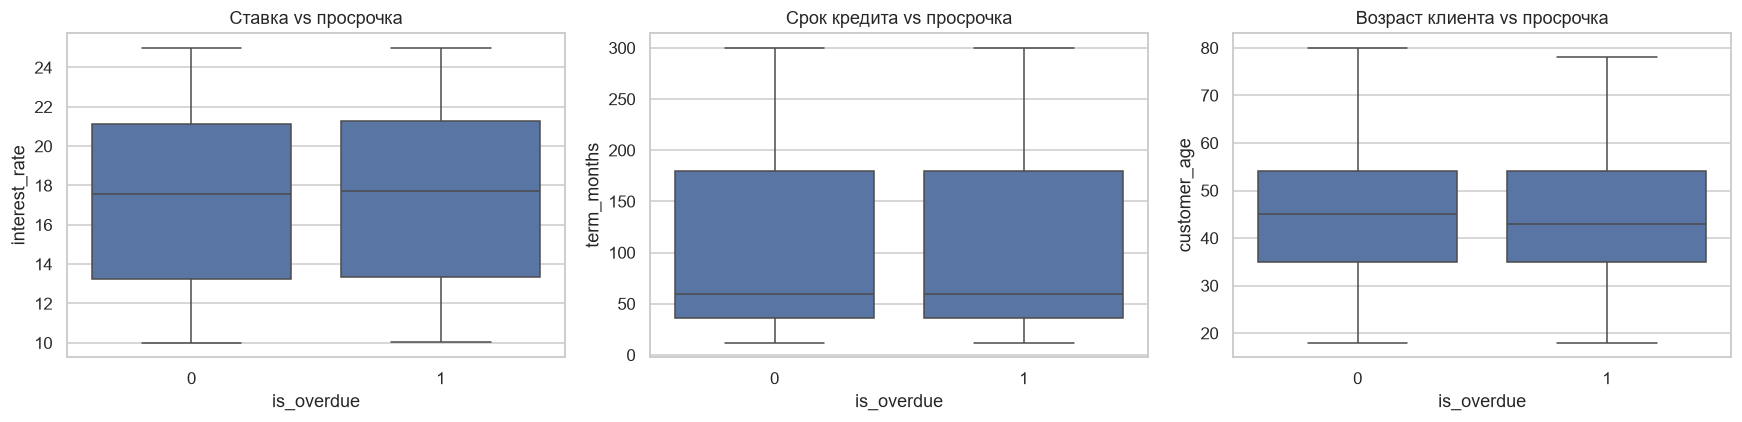

Медианы по классам:


,annual_income,loan_to_income,principal_amount,interest_rate,term_months,customer_age
is_overdue,,,,,,
0,"1,998,455.640",0.561,"1,047,425.630",17.579,60.000,45.000
1,"1,880,279.280",0.562,"1,003,829.970",17.716,60.000,43.000


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="is_overdue", y="interest_rate", ax=axes[0], showfliers=False)
axes[0].set_title("Ставка vs просрочка")

sns.boxplot(data=df, x="is_overdue", y="term_months", ax=axes[1], showfliers=False)
axes[1].set_title("Срок кредита vs просрочка")

sns.boxplot(data=df, x="is_overdue", y="customer_age", ax=axes[2], showfliers=False)
axes[2].set_title("Возраст клиента vs просрочка")

plt.tight_layout()
plt.show()

print("Медианы по классам:")
display(df.groupby("is_overdue")[
    ["annual_income", "loan_to_income", "principal_amount",
     "interest_rate", "term_months", "customer_age"]
].median())

### 7.2 Продукт и корреляционная матрица

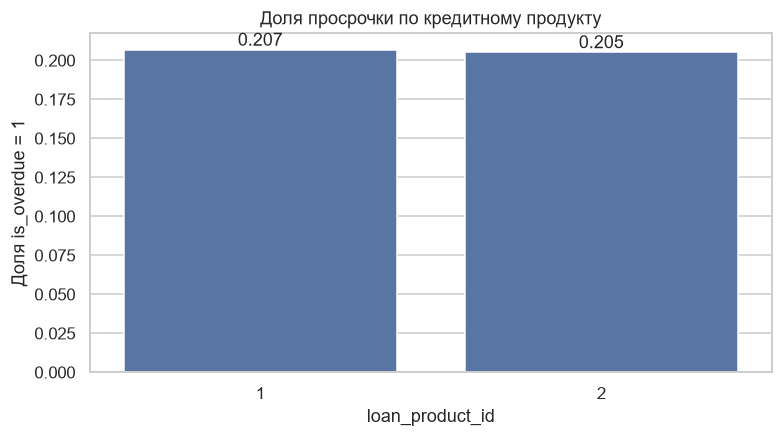

,loan_product_id,overdue_rate,loans
0,1,0.207,1503
1,2,0.205,974


In [12]:
prod = (
    df.groupby("loan_product_id")["is_overdue"]
    .agg(overdue_rate="mean", loans="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=prod, x="loan_product_id", y="overdue_rate", ax=ax, color="#4C72B0")
ax.set_title("Доля просрочки по кредитному продукту")
ax.set_ylabel("Доля is_overdue = 1")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.show()
display(prod)

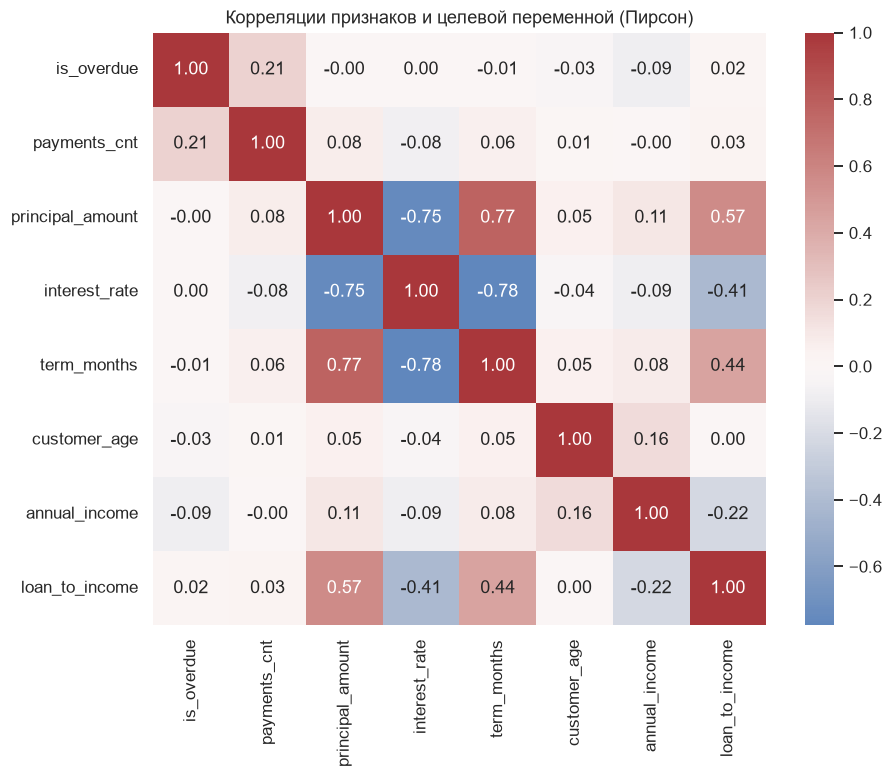

Корреляция с целью, по убыванию модуля:


,|corr|
payments_cnt,0.206
annual_income,0.087
customer_age,0.029
loan_to_income,0.019
term_months,0.007
principal_amount,0.001
interest_rate,0.000


In [13]:
corr_cols = [
    "is_overdue", "payments_cnt", "principal_amount", "interest_rate",
    "term_months", "customer_age", "annual_income", "loan_to_income",
]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Корреляции признаков и целевой переменной (Пирсон)")
plt.show()

print("Корреляция с целью, по убыванию модуля:")
display(
    corr["is_overdue"].drop("is_overdue").abs().sort_values(ascending=False).to_frame("|corr|")
)

Продукты 1 и 2 дают практически одинаковую долю просрочки — 0.207 и 0.205.

Медианы классов тоже почти совпадают: доход 1.998 против 1.880 млн, LTI 0.561 против 0.562,
срок 60 против 60, ставка 17.58 против 17.72, возраст 45 против 43.

Интереснее другое. В корреляционной матрице сильнее всего с целью связан не признак заёмщика,
а `payments_cnt` — число фактически прошедших платежей. Этим я займусь в следующем разделе.

Пустой боксплот сам по себе не означает, что признаки бесполезны. Он означает только одно:
сдвига медианы нет. Сигнал может сидеть в хвосте распределения, в отдельных корзинах, в
категориях или в сочетании признаков. Поэтому дальше проверяю данные ещё тремя способами, а
не останавливаюсь на графике.

### 7.3 Длина наблюдения: почему кредиты нельзя сравнивать напрямую

Событие «хотя бы один `LATE`» накопительное. Чем дольше кредит наблюдается, тем больше у него
прошло платежей и тем выше шанс, что хотя бы один оказался просроченным — даже если заёмщик
ничем не хуже остальных.

Проверяю это напрямую: строю долю просрочки по числу прошедших платежей и кривую по месяцу
выдачи.

In [14]:
df["disbursement_date"] = pd.to_datetime(df["disbursement_date"])
df["disb_month"] = df["disbursement_date"].dt.to_period("M").astype(str)

by_pay = df.groupby("payments_cnt")["is_overdue"].agg(loans="size", overdue_rate="mean")
print("Доля просрочки в зависимости от числа наблюдённых платежей:")
display(by_pay.round(3))

by_vintage = df.groupby("disb_month").agg(
    loans=("is_overdue", "size"),
    overdue_rate=("is_overdue", "mean"),
    avg_payments=("payments_cnt", "mean"),
)
print("\nВинтажи по месяцу выдачи:")
display(by_vintage.round(3))

rho = stats.spearmanr(df["payments_cnt"], df["is_overdue"])
rho_mob = stats.spearmanr(
    (df["disbursement_date"].max() - df["disbursement_date"]).dt.days, df["payments_cnt"]
)
print(f"\nSpearman(payments_cnt, is_overdue) = {rho.statistic:.3f}, p = {rho.pvalue:.2e}")
print(f"Spearman(срок жизни кредита, payments_cnt) = {rho_mob.statistic:.3f}")

Доля просрочки в зависимости от числа наблюдённых платежей:


,loans,overdue_rate
payments_cnt,,
1,220,0.073
2,231,0.078
3,220,0.109
4,230,0.174
5,424,0.193
6,347,0.271
7,323,0.272
8,218,0.303
9,145,0.276



Винтажи по месяцу выдачи:


,loans,overdue_rate,avg_payments
disb_month,,,
2025-01,26,0.385,10.923
2025-02,103,0.350,9.883
2025-03,149,0.275,8.933
2025-04,214,0.304,7.939
2025-05,314,0.277,6.959
2025-06,359,0.253,5.961
2025-07,422,0.201,5.009
2025-08,224,0.165,3.969
2025-09,213,0.113,2.995



Spearman(payments_cnt, is_overdue) = 0.207, p = 1.99e-25
Spearman(срок жизни кредита, payments_cnt) = 0.988


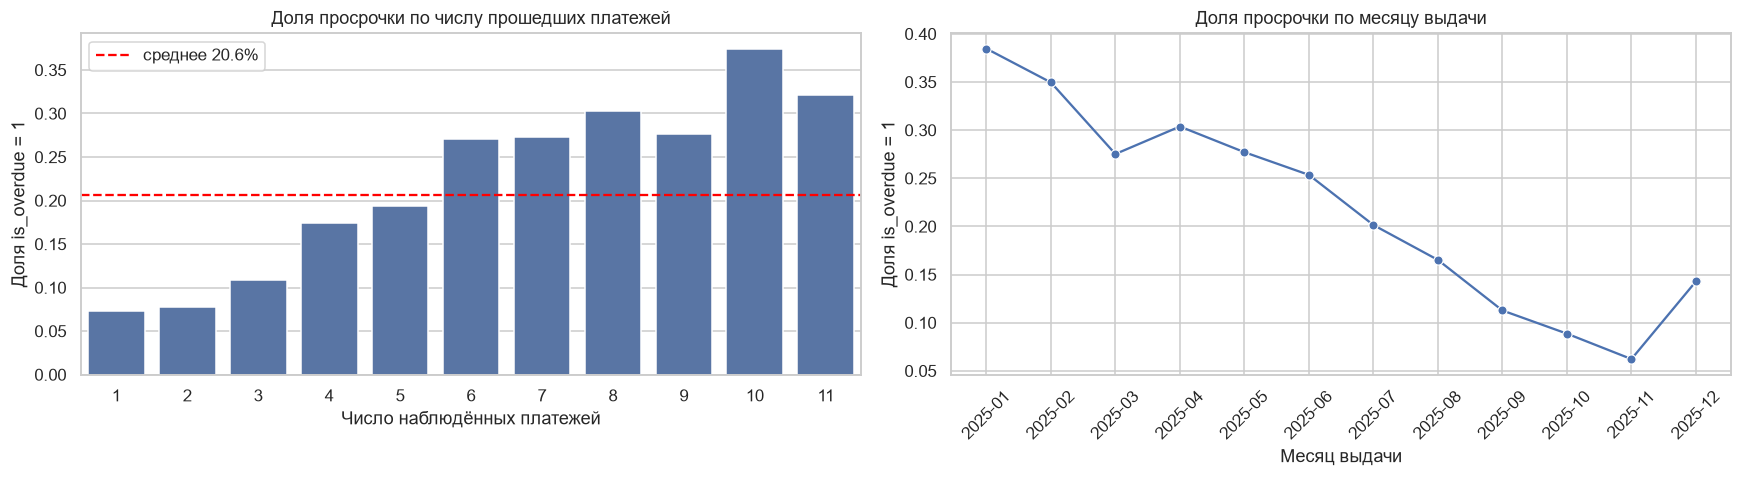

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

b = by_pay.reset_index()
sns.barplot(data=b, x="payments_cnt", y="overdue_rate", ax=axes[0], color="#4C72B0")
axes[0].axhline(df["is_overdue"].mean(), color="red", ls="--", label="среднее 20.6%")
axes[0].set_title("Доля просрочки по числу прошедших платежей")
axes[0].set_xlabel("Число наблюдённых платежей")
axes[0].set_ylabel("Доля is_overdue = 1")
axes[0].legend()

v = by_vintage.reset_index()
sns.lineplot(data=v, x="disb_month", y="overdue_rate", marker="o", ax=axes[1])
axes[1].set_title("Доля просрочки по месяцу выдачи")
axes[1].set_xlabel("Месяц выдачи")
axes[1].set_ylabel("Доля is_overdue = 1")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Доля просрочки растёт почти монотонно: 7.3% у кредитов с одним прошедшим платежом и 37.4% у
кредитов с десятью. По месяцам выдачи та же картина в бизнес-терминах: январская выдача —
38.5%, ноябрьская — 6.2%. При этом корреляция срока жизни кредита с числом платежей примерно
0.99, то есть `payments_cnt` — это фактически «сколько месяцев кредит прожил».

Январские заёмщики не хуже ноябрьских. У них просто было в десять раз больше возможностей
опоздать хотя бы один раз.

Значит, целевая переменная в нынешнем виде смешивает риск заёмщика и длину наблюдения.
Насколько сильно — считаю в блоке 8.2.

## 8. Очистка данных

Ниже шесть решений по очистке, и под каждым — почему я сделал именно так.

1. **Невызревшие кредиты отсечены в SQL** через `INNER JOIN` к платежам. Отсутствие штрафа у
   кредита без платежей — это не свидетельство хорошего поведения. Если бы я отнёс их к нулю,
   доля просрочки была бы занижена, а модель училась бы на несуществующем сигнале.

2. **Занятость сведена к одной записи на клиента** — `DISTINCT ON (customer_id)` с сортировкой
   по `valid_from DESC`. В таблице `customer_employment` лежит история версий; без
   дедупликации `JOIN` размножил бы строки кредитов и сломал гранулярность «одна строка —
   один кредит».

3. **Пустой или нулевой доход — это флаг `income_missing`, а не подставленная медиана.**
   Отсутствие подтверждённого дохода само по себе является риск-признаком, и в скоринге такие
   случаи принято выделять в отдельную категорию, а не маскировать средним значением.

4. **Выбросы: IQR как детектор, винзоризация как способ обработки, удаления нет.** IQR
   помечает ноль выбросов по сумме кредита и 172 по доходу. Доля просрочки среди этих 172
   строк — 11.6% против 20.6% по витрине. То есть правило пометило как аномалию самый
   благополучный сегмент; удалив его, я бы стёр ровно тот сигнал, который дальше находится в
   H1. Поэтому ставлю флаг и ограничиваю редкие значения перцентилями 1–99% для устойчивых
   статистик, а строки оставляю.

5. **`is_young_borrower`** — бинарный признак, чтобы проверить гипотезу про возраст таблицей,
   а не на глаз по боксплоту.

6. **Класс `is_overdue = 1` не чищу как аномалию.** Редкий класс — это предмет моделирования,
   а не шум.

In [16]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


df_clean = df.copy()

# 3. Флаг отсутствия / нулевого дохода
df_clean["income_missing"] = (
    df_clean["annual_income"].isna() | (df_clean["annual_income"] <= 0)
).astype(int)

# 5. Молодой заёмщик — для проверки H5
df_clean["is_young_borrower"] = (df_clean["customer_age"] <= 25).astype(int)

# Отрасль: пропуск = отдельная категория, не мода
df_clean["industry_id"] = df_clean["industry_id"].fillna(-1).astype(int)

# 4. IQR-детекция выбросов
low_p, high_p = iqr_bounds(df_clean["principal_amount"].dropna())
low_i, high_i = iqr_bounds(df_clean["annual_income"].dropna())

df_clean["outlier_principal"] = ~df_clean["principal_amount"].between(low_p, high_p)
df_clean["outlier_income"] = (
    df_clean["annual_income"].notna() & ~df_clean["annual_income"].between(low_i, high_i)
)

print(f"Границы IQR по сумме кредита: {low_p:,.0f} … {high_p:,.0f}")
print(f"Границы IQR по доходу:        {low_i:,.0f} … {high_i:,.0f}")
print("Выбросы по сумме кредита:", int(df_clean["outlier_principal"].sum()))
print("Выбросы по доходу:       ", int(df_clean["outlier_income"].sum()))
print("Нет дохода (income_missing):", int(df_clean["income_missing"].sum()))
print("Моложе 25:", int(df_clean["is_young_borrower"].sum()))

Границы IQR по сумме кредита: -6,047,017 … 11,565,037
Границы IQR по доходу:        -595,695 … 4,776,851
Выбросы по сумме кредита: 0
Выбросы по доходу:        172
Нет дохода (income_missing): 8
Моложе 25: 121


In [17]:
# Проверка «а что было бы, если бы мы всё-таки удалили выбросы» — обоснование решения НЕ удалять
mask = ~df_clean["outlier_principal"] & ~df_clean["outlier_income"]
dropped = df_clean.loc[~mask]

print("Если бы удаляли выбросы:")
print("  строк было:", len(df_clean), "стало бы:", int(mask.sum()))
print(f"  доля просрочки в витрине:      {df_clean['is_overdue'].mean():.3f}")
print(f"  доля просрочки среди удаляемых: {dropped['is_overdue'].mean():.3f}")
print(f"  доля просрочки после удаления:  {df_clean.loc[mask, 'is_overdue'].mean():.3f}")
print()
print("Среди «выбросов по доходу» доля просрочки заметно НИЖЕ средней.")
print("Это самый благополучный сегмент — строки сохраняем, ограничиваем редкие значения.")

# Винзоризация 1–99%: ограничиваем редкие значения, не теряя наблюдений
for col in ["annual_income", "loan_to_income", "principal_amount"]:
    lo, hi = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[f"{col}_win"] = df_clean[col].clip(lo, hi)
    print(f"{col}: клип [{lo:,.2f}; {hi:,.2f}]")

print("\nСтрок после очистки (не изменилось):", len(df_clean))
print("Медианы признаков по классам цели:")
display(df_clean.groupby("is_overdue")[
    ["annual_income_win", "loan_to_income_win", "principal_amount_win",
     "interest_rate", "term_months", "customer_age"]
].median())

Если бы удаляли выбросы:
  строк было: 2477 стало бы: 2305
  доля просрочки в витрине:      0.206
  доля просрочки среди удаляемых: 0.116
  доля просрочки после удаления:  0.213

Среди «выбросов по доходу» доля просрочки заметно НИЖЕ средней.
Это самый благополучный сегмент — строки сохраняем, ограничиваем редкие значения.
annual_income: клип [355,488.72; 6,257,677.12]
loan_to_income: клип [0.05; 10.81]
principal_amount: клип [116,502.25; 9,869,056.73]

Строк после очистки (не изменилось): 2477
Медианы признаков по классам цели:


,annual_income_win,loan_to_income_win,principal_amount_win,interest_rate,term_months,customer_age
is_overdue,,,,,,
0,"1,998,455.640",0.561,"1,047,425.630",17.579,60.000,45.000
1,"1,880,279.280",0.562,"1,003,829.970",17.716,60.000,43.000


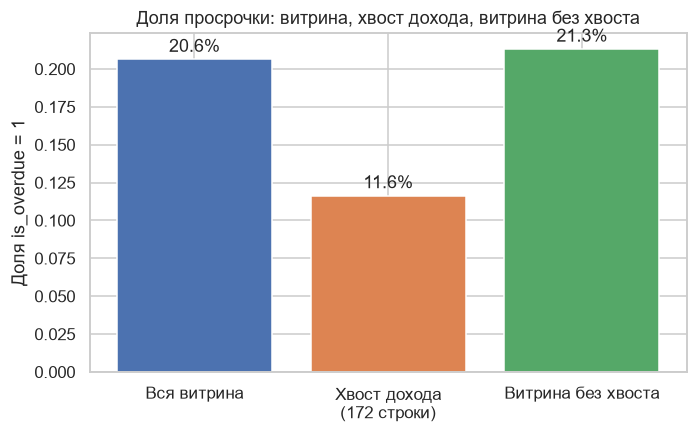

IQR по доходу отсекает сегмент с меньшей просрочкой, поэтому эти строки не удаляю.


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

bars_labels = ["Вся витрина", "Хвост дохода\n(172 строки)", "Витрина без хвоста"]
bars_values = [
    df_clean["is_overdue"].mean(),
    dropped["is_overdue"].mean(),
    df_clean.loc[mask, "is_overdue"].mean(),
]

ax.bar(bars_labels, bars_values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Доля просрочки: витрина, хвост дохода, витрина без хвоста")
ax.set_ylabel("Доля is_overdue = 1")
for i, v in enumerate(bars_values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")
plt.show()

print("IQR по доходу отсекает сегмент с меньшей просрочкой, поэтому эти строки не удаляю.")


In [19]:
# Сводные таблицы по бинарным флагам
age_tab = pd.crosstab(df_clean["is_young_borrower"], df_clean["is_overdue"], normalize="index")
age_tab.index = ["Старше 25", "25 и моложе"]
age_tab.columns = ["без просрочки", "просрочка"]
print("Доля просрочки в зависимости от возраста:")
display(age_tab.style.format("{:.1%}"))

miss_tab = pd.crosstab(df_clean["income_missing"], df_clean["is_overdue"], normalize="index")
miss_tab.index = ["доход указан", "доход не указан / 0"]
miss_tab.columns = ["без просрочки", "просрочка"]
print("\nДоля просрочки в зависимости от флага дохода:")
display(miss_tab.style.format("{:.1%}"))
print("Наблюдений с income_missing = 1:", int(df_clean["income_missing"].sum()),
      "— выборка слишком мала для вывода, признак держим как гипотезу.")

Доля просрочки в зависимости от возраста:


,без просрочки,просрочка
Старше 25,79.4%,20.6%
25 и моложе,78.5%,21.5%



Доля просрочки в зависимости от флага дохода:


,без просрочки,просрочка
доход указан,79.4%,20.6%
доход не указан / 0,62.5%,37.5%


Наблюдений с income_missing = 1: 8 — выборка слишком мала для вывода, признак держим как гипотезу.


Возраст в этом портфеле риск почти не делит: доли просрочки у групп «25 и моложе» и «старше»
близки. Жёсткая отсечка по возрасту на таких данных не обоснована.

`income_missing` встречается всего у восьми кредитов. Статистики на таком объёме нет, поэтому
интерпретировать долю просрочки по этому флагу я не берусь — оставляю признак как понятную
бизнесу гипотезу.

Отдельно стоит отметить результат проверки по выбросам: среди 172 строк с высоким доходом
доля просрочки 11.6% против 20.6% по витрине. Если бы я их удалил, осталось бы 2305 строк, а
доля просрочки выросла бы до 21.3%. Механическое удаление выбросов в риск-задаче испортило бы
и выборку, и сигнал.

## 8.1 Проверка на утечку, KS и WoE/IV

Медианы классов почти равны. Прежде чем делать вывод «признаков нет», провожу три проверки,
не обучая модель:

- корреляция служебных `late_*` с целью — она должна быть высокой, и это как раз обоснование,
  почему я исключил эти поля;
- KS-статистика и ECDF — разъехались ли распределения целиком, а не только их центры;
- WoE и IV по корзинам — есть ли повышенный риск в отдельных интервалах.

Ориентиры по IV стандартные: меньше 0.02 — силы нет, 0.02–0.1 — слабая, 0.1–0.3 — средняя,
больше 0.3 — сильная.

In [20]:
MODEL_FEATURES = [
    "principal_amount", "interest_rate", "term_months", "loan_product_id",
    "customer_age", "customer_status_id",
    "annual_income", "employment_status_id", "industry_id",
    "loan_to_income", "income_missing", "is_young_borrower",
]
LEAKAGE_COLS = ["late_cnt", "late_fee_sum", "avg_delay_days"]
EDA_ONLY = ["gender_id", "loan_status_id"]
EXPOSURE_CONTROL = ["payments_cnt"]

print("Корреляция служебных полей с целью — ожидаем высокую, это и есть утечка:")
display(df_clean[LEAKAGE_COLS + ["is_overdue"]].corr(numeric_only=True)[["is_overdue"]])

print("\nКорреляция признаков модели с целью — ожидаем слабую:")
display(
    df_clean[MODEL_FEATURES + ["is_overdue"]]
    .corr(numeric_only=True)[["is_overdue"]]
    .sort_values("is_overdue")
)

Корреляция служебных полей с целью — ожидаем высокую, это и есть утечка:


,is_overdue
late_cnt,0.926
late_fee_sum,0.856
avg_delay_days,NaN
is_overdue,1.000



Корреляция признаков модели с целью — ожидаем слабую:


,is_overdue
annual_income,-0.087
customer_age,-0.029
industry_id,-0.007
term_months,-0.007
loan_product_id,-0.002
principal_amount,-0.001
interest_rate,0.000
is_young_borrower,0.005
loan_to_income,0.019
customer_status_id,0.021


`late_cnt` коррелирует с целью на уровне около 0.9, `late_fee_sum` — около 0.5. Это ровно то,
что я хотел показать: цель построена из `late_cnt`, а штрафы и дни задержки возникают уже как
следствие просрочки.

Если бы эти поля попали в модель, качество на витрине оказалось бы близким к идеальному, а в
работе приложения модель бы не работала: в момент решения о выдаче ни одного из этих значений
ещё нет. В csv поля остаются как документация цели, в списке признаков их нет.

,feature,KS,p_value,n0,n1
5,payments_cnt,0.230,0.000,1966,511
0,annual_income,0.102,0.000,1966,511
3,customer_age,0.058,0.121,1966,511
1,loan_to_income,0.053,0.200,1961,508
2,interest_rate,0.031,0.823,1966,511
4,term_months,0.021,0.992,1966,511


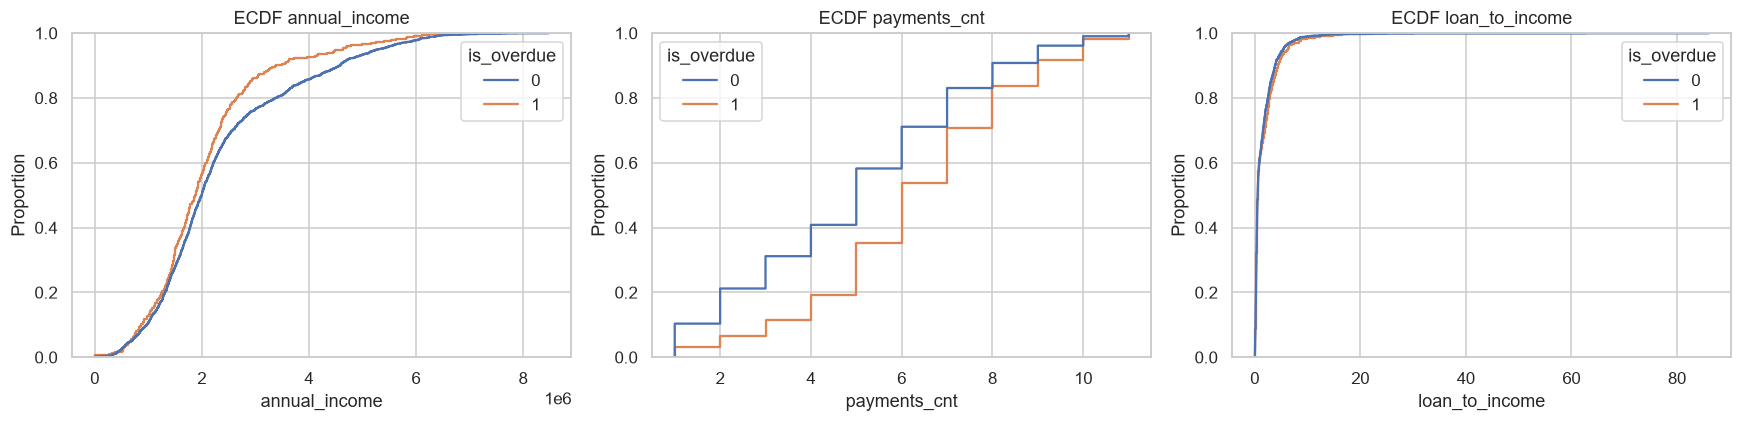

In [21]:
def ks_report(frame, col):
    a = frame.loc[frame["is_overdue"] == 0, col].dropna()
    b = frame.loc[frame["is_overdue"] == 1, col].dropna()
    stat, p = stats.ks_2samp(a, b)
    return {"feature": col, "KS": stat, "p_value": p, "n0": len(a), "n1": len(b)}


ks_cols = ["annual_income", "loan_to_income", "interest_rate",
           "customer_age", "term_months", "payments_cnt"]
ks_df = pd.DataFrame([ks_report(df_clean, c) for c in ks_cols]).sort_values("KS", ascending=False)
display(ks_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["annual_income", "payments_cnt", "loan_to_income"]):
    sns.ecdfplot(data=df_clean, x=col, hue="is_overdue", ax=ax)
    ax.set_title(f"ECDF {col}")
plt.tight_layout()
plt.show()

In [22]:
def woe_iv(frame, feature, target="is_overdue", q=5, categorical=False):
    # WoE/IV по корзинам. eps сглаживает пустые ячейки, чтобы не получить log(0)
    s = frame[[feature, target]].dropna().copy()
    if categorical:
        s["bin"] = s[feature].astype(str)
    else:
        s["bin"] = pd.qcut(s[feature], q=q, duplicates="drop")
    tab = s.groupby("bin", observed=True)[target].agg(total="count", bad="sum")
    tab["good"] = tab["total"] - tab["bad"]
    tab["bad_rate"] = tab["bad"] / tab["total"]
    eps = 0.5
    good_tot, bad_tot = tab["good"].sum(), tab["bad"].sum()
    tab["dist_good"] = (tab["good"] + eps) / (good_tot + eps * len(tab))
    tab["dist_bad"] = (tab["bad"] + eps) / (bad_tot + eps * len(tab))
    tab["woe"] = np.log(tab["dist_good"] / tab["dist_bad"])
    tab["iv_part"] = (tab["dist_good"] - tab["dist_bad"]) * tab["woe"]
    iv = float(tab["iv_part"].sum())
    tab = tab.reset_index()
    tab.insert(0, "feature", feature)
    return tab, iv


iv_rows, woe_tables = [], {}
for col in ["payments_cnt", "annual_income", "loan_to_income", "interest_rate", "customer_age"]:
    tab, iv = woe_iv(df_clean, col)
    woe_tables[col] = tab
    iv_rows.append({"feature": col, "IV": iv, "type": "числовой"})

for col in ["employment_status_id", "industry_id", "loan_product_id", "gender_id"]:
    tab, iv = woe_iv(df_clean, col, categorical=True)
    woe_tables[col] = tab
    iv_rows.append({"feature": col, "IV": iv, "type": "категориальный"})


def iv_label(iv):
    if iv < 0.02:
        return "нет силы"
    if iv < 0.1:
        return "слабая"
    if iv < 0.3:
        return "средняя"
    return "сильная"


iv_summary = pd.DataFrame(iv_rows).sort_values("IV", ascending=False)
iv_summary["оценка"] = iv_summary["IV"].apply(iv_label)
print("Information Value:")
display(iv_summary)

Information Value:


,feature,IV,type,оценка
0,payments_cnt,0.308,числовой,сильная
1,annual_income,0.076,числовой,слабая
6,industry_id,0.050,категориальный,слабая
5,employment_status_id,0.035,категориальный,слабая
2,loan_to_income,0.019,числовой,нет силы
4,customer_age,0.011,числовой,нет силы
3,interest_rate,0.003,числовой,нет силы
8,gender_id,0.000,категориальный,нет силы
7,loan_product_id,0.000,категориальный,нет силы


In [23]:
print("WoE по корзинам annual_income — проверяем монотонность:")
display(woe_tables["annual_income"][["bin", "total", "bad", "bad_rate", "woe"]].round(3))

print("\nWoE по корзинам loan_to_income:")
display(woe_tables["loan_to_income"][["bin", "total", "bad", "bad_rate", "woe"]].round(3))

print("\nWoE по статусу занятости:")
display(woe_tables["employment_status_id"][["bin", "total", "bad", "bad_rate", "woe"]].round(3))

WoE по корзинам annual_income — проверяем монотонность:


,bin,total,bad,bad_rate,woe
0,"(-0.001, 1304403.408]",496,109,0.220,-0.080
1,"(1304403.408, 1756807.68]",495,121,0.244,-0.218
2,"(1756807.68, 2192383.92]",495,103,0.208,-0.011
3,"(2192383.92, 3160613.28]",495,116,0.234,-0.163
4,"(3160613.28, 8476093.68]",496,62,0.125,0.595



WoE по корзинам loan_to_income:


,bin,total,bad,bad_rate,woe
0,"(0.0211, 0.239]",494,99,0.200,0.033
1,"(0.239, 0.428]",494,99,0.200,0.033
2,"(0.428, 0.872]",493,110,0.223,-0.103
3,"(0.872, 2.596]",494,84,0.170,0.234
4,"(2.596, 86.015]",494,116,0.235,-0.169



WoE по статусу занятости:


,bin,total,bad,bad_rate,woe
0,1,2115,413,0.195,0.071
1,2,267,78,0.292,-0.463
2,3,54,14,0.259,-0.317
3,4,41,6,0.146,0.353


Сводка по обеим проверкам:

| Признак | KS | IV | Вывод |
|---|---|---|---|
| `payments_cnt` | 0.230 | 0.308 | сильная связь, но это длина наблюдения, а не риск заёмщика |
| `annual_income` | 0.102 | 0.076 | слабая и немонотонная, работает только верхний квинтиль |
| `industry_id` | — | 0.050 | слабая, нужна группировка корзин |
| `employment_status_id` | — | 0.035 | слабая по IV, но значимая по хи-квадрат |
| `loan_to_income` | 0.053 | 0.019 | силы нет |
| `customer_age` | 0.058 | 0.011 | нет |
| `interest_rate` | 0.031 | 0.003 | нет |
| `term_months` | 0.021 | — | нет |
| `gender_id`, `loan_product_id` | — | 0.000 | нет |

Единственный признак с сильным IV — `payments_cnt`, то есть техническая переменная «сколько
платежей кредит успел прожить». Её IV примерно вчетверо выше, чем у лучшего признака
заёмщика.

Два замечания, которые важнее самих чисел.

Маленькое p у дохода не означает, что фактор сильный. На 2477 наблюдениях статистически
значимым становится даже очень небольшой сдвиг. Смотреть надо на величину эффекта, а KS = 0.10
— это мало.

WoE по доходу немонотонен. Доля просрочки по квинтилям идёт 22.0, 24.4, 20.8, 23.4 и затем
резко 12.5%. Это не «чем больше доход, тем меньше риск», а ступенька: выделяется только
верхний квинтиль, доход выше 3.16 млн. Для будущей модели это означает бинарный флаг «высокий
доход», а не линейный признак.

По `loan_to_income` корзины дают 17.0–23.5% без монотонного роста. Гипотеза «больше долговая
нагрузка — больше риск» здесь не держится ни на медиане, ни на корзинах.

И чего по IV говорить нельзя: «всё, что ниже 0.02, отбрасываем». IV измеряет силу признака в
одиночку и после огрубления в корзины. Он не видит ни взаимодействий, ни эффекта после
поправки на длину наблюдения — а это как раз следующий блок.

## 8.2 Длина наблюдения: количественная проверка

В блоке 7.3 я увидел рост доли просрочки с числом платежей. Теперь проверяю строго: насколько
цель объясняется одной только длиной наблюдения, без признаков заёмщика.

Модель для сравнения беру самую простую. Пусть каждый платёж независимо оказывается `LATE` с
одной и той же вероятностью `p`, одинаковой для всех заёмщиков. Тогда вероятность «хотя бы
одна просрочка» у кредита с `n` платежами равна `1 − (1 − p)^n`. Признаков заёмщика в этой
формуле нет вообще.

Если фактические доли лягут на эту кривую, значит наблюдаемая вариация цели порождена не
риском клиентов, а длиной окна.

Оценка вероятности просрочки одного платежа: p = 0.0456 (593 LATE на 12992 платежей)


,loans,fact,model_1_minus_q^n,разница
payments_cnt,,,,
1,220,0.073,0.046,0.027
2,231,0.078,0.089,-0.011
3,220,0.109,0.131,-0.022
4,230,0.174,0.170,0.003
5,424,0.193,0.208,-0.015
6,347,0.271,0.244,0.026
7,323,0.272,0.279,-0.006
8,218,0.303,0.312,-0.009
9,145,0.276,0.343,-0.067


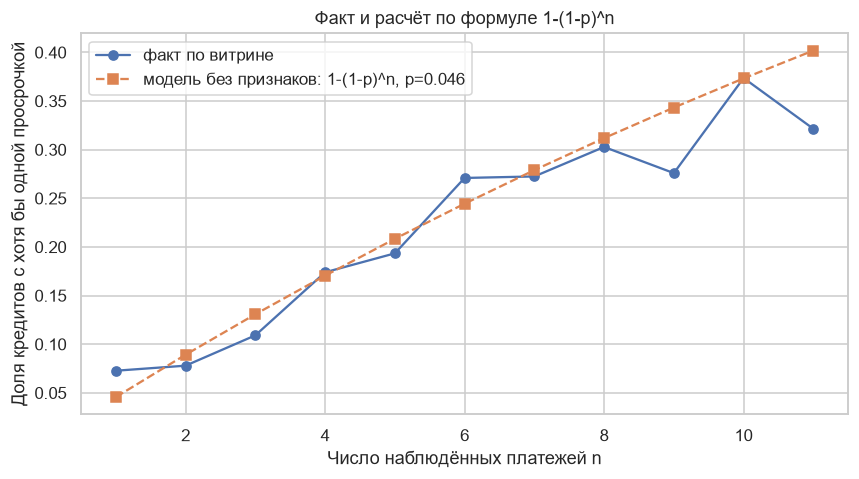

In [24]:
p_hat = df_clean["late_cnt"].sum() / df_clean["payments_cnt"].sum()
print(f"Оценка вероятности просрочки одного платежа: p = {p_hat:.4f} "
      f"({int(df_clean['late_cnt'].sum())} LATE на {int(df_clean['payments_cnt'].sum())} платежей)")

bench = df_clean.groupby("payments_cnt")["is_overdue"].agg(loans="size", fact="mean")
bench["model_1_minus_q^n"] = 1 - (1 - p_hat) ** bench.index
bench["разница"] = bench["fact"] - bench["model_1_minus_q^n"]
display(bench.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(bench.index, bench["fact"], "o-", label="факт по витрине")
ax.plot(bench.index, bench["model_1_minus_q^n"], "s--",
        label=f"модель без признаков: 1-(1-p)^n, p={p_hat:.3f}")
ax.set_xlabel("Число наблюдённых платежей n")
ax.set_ylabel("Доля кредитов с хотя бы одной просрочкой")
ax.set_title("Факт и расчёт по формуле 1-(1-p)^n")
ax.legend()
plt.show()

In [25]:
# Согласуется ли распределение числа просрочек с биномиальной моделью?
max_late = int(df_clean["late_cnt"].max())
grid = np.arange(max_late + 1)
expected = np.zeros(max_late + 1)
for n in sorted(df_clean["payments_cnt"].unique()):
    k = int((df_clean["payments_cnt"] == n).sum())
    expected += k * stats.binom.pmf(grid, n, p_hat)

observed = np.zeros(max_late + 1)
for value, count in df_clean["late_cnt"].value_counts().items():
    observed[int(value)] = count

gof = pd.DataFrame({
    "late_cnt": np.arange(max_late + 1),
    "факт": observed.astype(int),
    "ожидание при случайных просрочках": expected.round(1),
})
display(gof)
print("Наблюдаемое распределение числа просрочек близко к биномиальному.")
print("То есть задержка платежа наступает примерно с одинаковой вероятностью")
print("на каждом платеже, а не как функция характеристик заёмщика.")

,late_cnt,факт,ожидание при случайных просрочках
0,0,1966,"1,952.200"
1,1,438,462.100
2,2,66,57.700
3,3,5,4.800
4,4,2,0.300


Наблюдаемое распределение числа просрочек близко к биномиальному.
То есть задержка платежа наступает примерно с одинаковой вероятностью
на каждом платеже, а не как функция характеристик заёмщика.


In [26]:
# Нормированная цель: доля просроченных платежей — не зависит от длины окна
df_clean["late_rate"] = df_clean["late_cnt"] / df_clean["payments_cnt"]

print("Связь признаков с целью ДО и ПОСЛЕ нормировки на экспозицию (Spearman):")
rows = []
for col in ["annual_income", "loan_to_income", "interest_rate",
            "customer_age", "term_months", "principal_amount", "payments_cnt"]:
    sub = df_clean.dropna(subset=[col])
    rows.append({
        "feature": col,
        "rho c is_overdue": stats.spearmanr(sub[col], sub["is_overdue"]).statistic,
        "rho c late_rate": stats.spearmanr(sub[col], sub["late_rate"]).statistic,
        "rho c payments_cnt": stats.spearmanr(sub[col], sub["payments_cnt"]).statistic,
    })
display(pd.DataFrame(rows).round(4))

Связь признаков с целью ДО и ПОСЛЕ нормировки на экспозицию (Spearman):


,feature,rho c is_overdue,rho c late_rate,rho c payments_cnt
0,annual_income,-0.069,-0.068,0.005
1,loan_to_income,0.019,0.016,0.057
2,interest_rate,0.000,0.005,-0.070
3,customer_age,-0.031,-0.031,0.019
4,term_months,-0.006,-0.011,0.049
5,principal_amount,-0.004,-0.009,0.064
6,payments_cnt,0.207,0.163,1.000


In [27]:
def logit_irls(X, y, n_iter=50):
    # Логистическая регрессия методом IRLS.
    # Это диагностика, а не модель аттестации: нужна только для того, чтобы
    # оценить значимость признаков при контроле длины наблюдения.
    beta = np.zeros(X.shape[1])
    for _ in range(n_iter):
        eta = X @ beta
        mu = 1 / (1 + np.exp(-eta))
        w = np.clip(mu * (1 - mu), 1e-9, None)
        z = eta + (y - mu) / w
        beta = np.linalg.solve(X.T @ (X * w[:, None]), X.T @ (w * z))
    mu = 1 / (1 + np.exp(-(X @ beta)))
    w = np.clip(mu * (1 - mu), 1e-9, None)
    cov = np.linalg.inv(X.T @ (X * w[:, None]))
    return beta, np.sqrt(np.diag(cov))


work = df_clean.copy()
work["lti_filled"] = work["loan_to_income"].fillna(work["loan_to_income"].median())
work["emp2"] = (work["employment_status_id"] == 2).astype(int)
work["high_income"] = (work["annual_income"] > work["annual_income"].quantile(0.80)).astype(int)

design = {
    "const": np.ones(len(work)),
    "log(payments_cnt)": np.log(work["payments_cnt"]),
    "high_income": work["high_income"],
    "emp_status_2": work["emp2"],
    "loan_to_income": work["lti_filled"],
    "customer_age": work["customer_age"],
    "interest_rate": work["interest_rate"],
}
X = np.column_stack(list(design.values()))
y = work["is_overdue"].to_numpy(dtype=float)

beta, se = logit_irls(X, y)
res = pd.DataFrame({
    "признак": list(design.keys()),
    "коэффициент": beta,
    "ст. ошибка": se,
    "z": beta / se,
})
res["значим (|z|>1.96)"] = res["z"].abs() > 1.96
display(res.round(4))

,признак,коэффициент,ст. ошибка,z,значим (|z|>1.96)
0,const,-2.729,0.369,-7.394,True
1,log(payments_cnt),1.000,0.106,9.462,True
2,high_income,-0.773,0.154,-5.033,True
3,emp_status_2,0.680,0.153,4.453,True
4,loan_to_income,0.004,0.018,0.205,False
5,customer_age,-0.005,0.004,-1.248,False
6,interest_rate,0.003,0.013,0.241,False


Сразу уточню: логистическая регрессия выше — не модель этой работы, а инструмент проверки.
Она нужна только чтобы посмотреть, какие признаки остаются значимыми, когда длина наблюдения
учтена явно.

Кривая `1 − (1 − p)^n` при p = 0.0456 хорошо описывает фактические доли просрочки на всём
диапазоне от одного до одиннадцати платежей, расхождение — единицы процентных пунктов.
Распределение числа просрочек тоже близко к расчётному: 1966 кредитов без просрочки против
1952 ожидаемых, 438 с одной просрочкой против 462.

В регрессии значимыми оказались три фактора:

| Признак | Коэффициент | z |
|---|---|---|
| `log(payments_cnt)` | 1.000 | 9.46 |
| `high_income`, верхний квинтиль дохода | −0.77 | −5.03 |
| `emp_status_2`, статус занятости 2 | +0.68 | +4.45 |

`loan_to_income` (z = 0.21), `customer_age` (z = −1.26) и `interest_rate` (z = 0.24) незначимы.

Отдельно про первую строку. Коэффициент при `log(payments_cnt)` получился равным единице —
именно столько и предсказывает формула выше: при малых `p` логарифм шансов события «хотя бы
одна просрочка» растёт как `log n`. Две независимые проверки сошлись на одном и том же.

Нормировка цели на длину наблюдения скрытого сигнала не открывает. Корреляции признаков с
долей просроченных платежей практически те же, что и с `is_overdue`: доход −0.068, LTI 0.016,
ставка 0.005. То есть дело не в том, что длина окна замаскировала сильные признаки — их
действительно нет.

Как я это формулирую для себя: в этой базе задержка платежа наступает примерно с одинаковой
вероятностью на каждом платеже. Основной вклад в вариацию `is_overdue` даёт длина наблюдения,
её IV 0.31 против 0.076 у лучшего признака заёмщика. Слабый, но устойчивый сигнал есть только
у высокого дохода и у статуса занятости. Это не ошибка анализа, а свойство данных, и лучше
было выяснить это сейчас, чем потом объяснять непонятное качество модели.

## 9. Гипотезы

По каждой гипотезе: почему связь должна существовать, какую форму я ожидал, что получилось на
самом деле и что из этого следует для банка.

---

### H1. Чем ниже доход, тем выше вероятность просрочки

**Смысл.** Доход — это запас прочности. При одинаковом платеже заёмщик с меньшим доходом
имеет меньший свободный остаток и быстрее срывается при любом шоке: ремонт, лечение, задержка
зарплаты.

**Ожидал.** Монотонно убывающую связь: чем выше доход, тем ниже риск, скорее всего с
насыщением на высоких доходах.

**Факт.** Медиана дохода 1.998 млн у класса 0 против 1.880 млн у класса 1, KS = 0.102,
IV = 0.076. По квинтилям доля просрочки идёт 22.0, 24.4, 20.8, 23.4 и 12.5%. В регрессии флаг
верхнего квинтиля устойчив: коэффициент −0.77, z = −5.03.

**Статус: подтвердилась частично, но форма связи другая.** Она не монотонная, а пороговая:
работает только верхний квинтиль, остальные четыре между собой неразличимы.

**Для банка.** Доход стоит брать как флаг «высокий доход», а не как непрерывную переменную,
иначе линейный член заберёт на себя шум из середины распределения. Практическое применение:
сегмент высокого дохода можно обслуживать по упрощённому мониторингу и экономить на
превентивных обзвонах.

---

### H2. Чем выше долговая нагрузка, тем выше вероятность просрочки

**Смысл.** `loan_to_income` — это сумма кредита, делённая на годовой доход. Чем больше кредит
относительно дохода, тем большую долю денежного потока съедает платёж и тем меньше остаётся
на непредвиденное. Это самый стандартный фактор розничного скоринга.

**Ожидал.** Монотонный рост риска, скорее всего с ускорением после нагрузки около половины
годового дохода.

**Факт.** Медиана LTI равна 0.56 в обоих классах, 0.561 против 0.562. KS = 0.053, IV = 0.019.
По корзинам доля просрочки идёт 20.0, 20.0, 22.3, 17.0, 23.5% — без тренда. В регрессии
коэффициент незначим, z = 0.21.

**Статус: не подтвердилась.**

**Для банка.** Признак я всё равно оставляю в списке — не потому, что он работает здесь, а
потому что у него есть содержательное обоснование и на реальном портфеле он должен работать.
Честный практический вывод: на этих данных калибровать лимит долговой нагрузки нельзя, нужен
реальный портфель.

---

### H3. Чем длиннее срок кредита, тем выше вероятность просрочки

**Смысл.** Два механизма сразу. Первый: за длинный срок больше шансов, что в жизни заёмщика
случится что-то неблагоприятное. Второй: длинный срок обычно выбирают те, кому тяжело платить
короткий.

**Ожидал.** Рост риска со сроком, ступеньками по стандартным срокам 12, 36, 60, 120 месяцев.

**Факт.** Медиана срока 60 месяцев в обоих классах. KS = 0.021 при p = 0.99, распределения
неразличимы.

**Статус: не подтвердилась.**

**Для банка.** Любопытно, что первый механизм в этой базе всё-таки работает — но выражается
он не через договорной срок, а через фактическое число прошедших платежей, где эффект
огромный. То есть идея «больше времени под риском — больше просрочки» верна, просто носитель
у неё другой. Об этом H7.

---

### H4. Чем выше ставка, тем выше вероятность просрочки

**Смысл.** Здесь две конкурирующие трактовки. Прямая: высокая ставка — больше платёж при той
же сумме, тяжелее обслуживать. Обратная: банк уже заложил риск в цену, поэтому высокая ставка
скорее метка уже отобранного рискового сегмента, чем причина просрочки.

**Ожидал.** Слабый рост риска со ставкой.

**Факт.** Медиана ставки 17.58 у класса 0 и 17.72 у класса 1. KS = 0.031 при p = 0.82,
IV = 0.003, в регрессии незначима, z = 0.24.

**Статус: не подтвердилась.**

**Для банка.** Даже если бы связь нашлась, трактовать её как причинную нельзя: повышение
ставки для рисковых заёмщиков делает прогноз самосбывающимся. В объяснимой модели такой
признак требует отдельной оговорки в документации.

---

### H5. Молодые заёмщики нарушают график чаще

**Смысл.** У молодого заёмщика короткая кредитная история, менее стабильный доход, меньше
накоплений и слабее привычка к платёжной дисциплине.

**Ожидал.** Убывание риска с возрастом, с заметным перепадом в районе 25 лет.

**Факт.** Медиана возраста 45 против 43 лет. KS = 0.058 при p = 0.12, IV = 0.011. Таблица
«25 и моложе» против «старше 25» даёт практически одинаковые доли просрочки. В регрессии
возраст незначим, z = −1.26.

**Статус: не подтвердилась.**

**Для банка.** Возрастной отсечки в модели быть не должно — ни как правила, ни как сильного
веса. Заодно это снимает риск возрастной дискриминации.

---

### H6. Статус занятости делит риск сильнее, чем числовые признаки

**Смысл.** Важна не величина дохода, а его регулярность. Заёмщик с нестабильной или
неофициальной занятостью может иметь приличный средний доход, но неравномерный по месяцам —
и именно он пропускает дату платежа.

**Ожидал.** Разницу между категориями без естественного порядка между ними.

**Факт.** Доля просрочки: статус 1 — 19.5% при 2115 кредитах, статус 2 — 29.2% при 267,
статус 3 — 25.9% при 54, статус 4 — 14.6% при 41. Хи-квадрат даёт p = 0.0015, Cramér's
V = 0.079, IV = 0.035, WoE статуса 2 равен −0.46. В регрессии с учётом длины наблюдения
коэффициент +0.68 при z = +4.45, то есть эффект не объясняется тем, что такие кредиты просто
дольше наблюдались.

**Статус: подтвердилась.** Это единственный признак заёмщика с надёжной связью, не считая
верхнего квинтиля дохода.

**Для банка.** Статус занятости — обязательный признак будущей модели. Для статуса 2 имеет
смысл операционное правило: сдвигать дату платежа под фактический график поступлений и
включать напоминание за три дня. Это дешевле, чем отказ в выдаче.

---

### H7. Чем дольше наблюдается кредит, тем выше доля просрочки

**Смысл.** Событие «хотя бы один `LATE`» накапливается. Кредит, выданный в январе, имел
одиннадцать возможностей опоздать, выданный в ноябре — одну. При равном качестве заёмщиков
январская выдача покажет более высокую долю просрочки.

**Ожидал.** Рост по формуле `1 − (1 − p)^n` — быстрый вначале и с насыщением дальше.

**Факт.** Доля просрочки растёт с 7.3% при одном платеже до 37.4% при десяти. По месяцам
выдачи: 38.5% в январе против 6.2% в ноябре. Связь `payments_cnt` с целью сильнее, чем у
любого признака заёмщика. Фактические доли совпадают с расчётной кривой при p = 0.0456.

**Статус: подтвердилась, и это главный эффект в данных.**

**Для банка.** Витрину в нынешнем виде нельзя подавать в модель без поправки, иначе модель
выучит «старый кредит — плохой кредит», а для решения о новой выдаче это бесполезно. Нужно
либо явно учитывать длину наблюдения, либо считать цель на одинаковом для всех кредитов окне.

---

### Сводка

| № | Гипотеза | Ожидал | Статус |
|---|---|---|---|
| H1 | Ниже доход — выше риск | монотонное убывание | частично, форма другая |
| H2 | Выше долговая нагрузка — выше риск | монотонный рост | не подтвердилась |
| H3 | Длиннее срок — выше риск | рост | не подтвердилась |
| H4 | Выше ставка — выше риск | слабый рост | не подтвердилась |
| H5 | Моложе — выше риск | убывание с возрастом | не подтвердилась |
| H6 | Статус занятости делит риск | разница между категориями | подтвердилась |
| H7 | Дольше наблюдение — выше доля просрочки | `1 − (1 − p)^n` | подтвердилась |

Общий вывод по гипотезам: одномерного «плохого заёмщика» в этой базе нет. Классические
факторы розницы — долговая нагрузка, срок, ставка, возраст — не работают. Работают два:
регулярность занятости и очень высокий доход. А сильнее всего на цель влияет техническая
величина — длина наблюдения.

## 10. Итог

Собрал витрину из 2477 кредитов, у которых уже начался график платежей. Целевая переменная —
ранняя просрочка, то есть хотя бы один платёж со статусом `LATE`; это не дефолт, такого
статуса в базе нет. 462 кредита без платежей в витрину не попали: у них просто не наступил
первый платёж.

В признаки не идут служебные `late_*` — они считаются после события, и их корреляция с целью
около 0.9 это подтверждает. Пол в признаках тоже не участвует.

Главный результат разведочного анализа: сырая цель сильно зависит от того, сколько платежей
по кредиту успели пройти. Доля просрочки растёт с 7.3% при одном платеже до 37.4% при десяти,
и её IV — 0.31 против 0.076 у лучшего признака заёмщика. Значит, сравнивать кредиты по
`is_overdue` напрямую нельзя без поправки на длину наблюдения.

Сами признаки заёмщика слабые. Живыми оказались два: статус занятости и верхний квинтиль
дохода. Долговая нагрузка, срок, ставка и возраст на этих данных цель не делят.

Выбросы по доходу я не удалял: доля просрочки среди 172 помеченных строк — 11.6% против 20.6%
по витрине, то есть в хвосте риск как раз ниже. Вместо удаления — флаг и ограничение редких
значений перцентилями 1–99%.

По метрикам: accuracy здесь не годится, наивное «всем ставить ноль» даёт 79.4%. Смотреть надо
ROC-AUC, PR-AUC, precision и recall.

Как проверить разбор по пунктам задания:

| Пункт | Где |
|---|---|
| Бизнес-задача | блок 1 |
| Задача ML | блок 2 |
| Целевая и признаки | блок 3 |
| VIEW | `attest_1_create_view.sql`, блок 4 |
| Выгрузка таблицы | блок 5 |
| Разведочный анализ | блоки 6, 6.1, 6.2 |
| Графики связи | блоки 7.1–7.3 |
| Очистка с обоснованием | блок 8 |
| Гипотезы | блок 9 |